# Binary Baseline
## 1.1 Import Data and Required Packages
### Importing Pandas, NumPy, MatPlotLib, Seaborn, and Warnings libraries

In [23]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping
import warnings

### Import the CSV data as Pandas dataframe

In [3]:
df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")

### Add BMI Age interaction

In [4]:
df["BMI_Age"] = df["BMI"] * df["Age"]

### Preparing X and Y variables

In [5]:
X = df.drop(columns=["Diabetes_012"], axis=1)
Y = df["Diabetes_012"]
y_binary = (Y != 0).astype(int)

In [6]:
# Create column transformer (Categorical features included in case some are engineered later)
num_features = X.select_dtypes(exclude=["object"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [7]:
X = preprocessor.fit_transform(X)

In [8]:
# Train-test split
x_train_full, x_test, y_train_full, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
x_train_full.shape, x_test.shape

((202944, 22), (50736, 22))

In [9]:
# Validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

### Create an evaluation function to give all metrics after training

In [25]:
def evaluate_model(true, predicted, proba):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted, zero_division=0)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    roc_auc = roc_auc_score(true, proba)
    conf_matrix = confusion_matrix(true, predicted)
    pr_curve = precision_recall_curve(true, proba)

    return accuracy, precision, recall, f1, roc_auc, conf_matrix, pr_curve

In [29]:
# Get scale_pos_weight for XGBoost
negative_count = np.sum(y_train_full == 0)
positive_count = np.sum(y_train_full == 1)

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced"),
    "Random Forest Classifier": RandomForestClassifier(class_weight="balanced"),
    "Support Vector Machine": CalibratedClassifierCV(LinearSVC(class_weight="balanced"), method="sigmoid"),
    "K-Neighbors Classifier": KNeighborsClassifier(n_jobs=-1, weights="distance"),
    "XGBoost Classifier": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, tree_method="hist", device="cuda", n_jobs=-1, eval_metric="logloss", objective="binary:logistic", early_stopping_rounds=10, scale_pos_weight=(negative_count / positive_count)),
    "CatBoost Classifier": CatBoostClassifier(n_estimators=500, depth=6, learning_rate=0.1, task_type="GPU", verbose=False, early_stopping_rounds=50, loss_function="Logloss", auto_class_weights="Balanced"),
    "LightGBM Classifier": LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, device="gpu", verbose=0, objective="binary", class_weight="balanced")
}
model_list = []
threshold_list = []
rec_list = []
prec_list = []
roc_auc_list = []
f1_list = []
combined_list = []
confusion_matrix_list = []
pr_curve_list = []

for i in range(len(list(models))):

    # Train model
    model = list(models.values())[i]

    # Call correct fit method
    if model.__class__.__name__ == "LGBMClassifier":
        callbacks = [early_stopping(stopping_rounds=10, verbose=0)]
        model.fit(x_train, y_train, eval_set=[(x_val, y_val)], eval_metric="logloss", callbacks=callbacks)
    elif model.__class__.__name__ == "XGBClassifier":
        model.fit(x_train, y_train, eval_set=[(x_val, y_val)], verbose=0)
    elif model.__class__.__name__ == "CatBoostClassifier":
        model.fit(x_train, y_train, eval_set=(x_val, y_val))
    else:
        model.fit(x_train_full, y_train_full)

    for t in [0.5, 0.4, 0.3, 0.2]:
        
        # Get predicted probabilities
        y_train_proba = model.predict_proba(x_train_full)
        y_test_proba = model.predict_proba(x_test)

        y_train_proba_pos = y_train_proba[:, 1]
        y_test_proba_pos = y_test_proba[:, 1]

        # Apply threshold to predicted probabilities
        y_train_pred = (y_train_proba_pos > t).astype(int)
        y_test_pred = (y_test_proba_pos > t).astype(int)

        # Evaluate model
        train_acc, train_prec, train_rec, train_f1, train_roc_auc, train_matrix, train_pr_curve = evaluate_model(y_train_full, y_train_pred, y_train_proba_pos)
        test_acc, test_prec, test_rec, test_f1, test_roc_auc, test_matrix, test_pr_curve = evaluate_model(y_test, y_test_pred, y_test_proba_pos)

        print(list(models.keys())[i])
        print("Threshold: {:.2f}".format(t))

        model_list.append(list(models.keys())[i])
        threshold_list.append(t)

        print("Model performance for training set:")
        print("- Accuracy: {:.4f}".format(train_acc))
        print("- Precision: {:.4f}".format(train_prec))
        print("- Recall: {:.4f}".format(train_rec))
        print("- F1 Score: {:.4f}".format(train_f1))
        print("- ROC AUC: {:.4f}".format(train_roc_auc))

        print("-------------------------------------------")

        print("Model performance for test set:")
        print("- Accuracy: {:.4f}".format(test_acc))
        print("- Precision: {:.4f}".format(test_prec))
        print("- Recall: {:.4f}".format(test_rec))
        print("- F1 Score: {:.4f}".format(test_f1))
        print("- ROC AUC: {:.4f}".format(test_roc_auc))

        rec_list.append(test_rec)
        prec_list.append(test_prec)
        roc_auc_list.append(test_roc_auc)
        f1_list.append(test_f1)

        # Combined metric (weighted average of recall, roc_auc, and f1 score)
        combined_score = (0.5 * test_rec) + (0.3 * test_roc_auc) + (0.2 * test_f1)
        combined_list.append(combined_score)

        confusion_matrix_list.append(test_matrix)
        
        if t == 0.5:
            pr_curve_list.append(test_pr_curve)

        print('=' * 35)
        print("\n")

Logistic Regression
Threshold: 0.50
Model performance for training set:
- Accuracy: 0.7326
- Precision: 0.3429
- Recall: 0.7601
- F1 Score: 0.4726
- ROC AUC: 0.8194
-------------------------------------------
Model performance for test set:
- Accuracy: 0.7340
- Precision: 0.3439
- Recall: 0.7581
- F1 Score: 0.4732
- ROC AUC: 0.8194


Logistic Regression
Threshold: 0.40
Model performance for training set:
- Accuracy: 0.6659
- Precision: 0.3016
- Recall: 0.8514
- F1 Score: 0.4455
- ROC AUC: 0.8194
-------------------------------------------
Model performance for test set:
- Accuracy: 0.6655
- Precision: 0.3007
- Recall: 0.8468
- F1 Score: 0.4438
- ROC AUC: 0.8194


Logistic Regression
Threshold: 0.30
Model performance for training set:
- Accuracy: 0.5810
- Precision: 0.2628
- Recall: 0.9188
- F1 Score: 0.4087
- ROC AUC: 0.8194
-------------------------------------------
Model performance for test set:
- Accuracy: 0.5822
- Precision: 0.2631
- Recall: 0.9168
- F1 Score: 0.4088
- ROC AUC: 0

e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier
Threshold: 0.50
Model performance for training set:
- Accuracy: 0.7241
- Precision: 0.3402
- Recall: 0.7992
- F1 Score: 0.4773
- ROC AUC: 0.8332
-------------------------------------------
Model performance for test set:
- Accuracy: 0.7208
- Precision: 0.3347
- Recall: 0.7814
- F1 Score: 0.4687
- ROC AUC: 0.8241




e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier
Threshold: 0.40
Model performance for training set:
- Accuracy: 0.6605
- Precision: 0.3014
- Recall: 0.8754
- F1 Score: 0.4484
- ROC AUC: 0.8332
-------------------------------------------
Model performance for test set:
- Accuracy: 0.6587
- Precision: 0.2978
- Recall: 0.8587
- F1 Score: 0.4422
- ROC AUC: 0.8241




e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier
Threshold: 0.30
Model performance for training set:
- Accuracy: 0.5870
- Precision: 0.2669
- Recall: 0.9279
- F1 Score: 0.4146
- ROC AUC: 0.8332
-------------------------------------------
Model performance for test set:
- Accuracy: 0.5848
- Precision: 0.2642
- Recall: 0.9158
- F1 Score: 0.4101
- ROC AUC: 0.8241




e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\Projects\Diabetes Risk Prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier
Threshold: 0.20
Model performance for training set:
- Accuracy: 0.4992
- Precision: 0.2349
- Recall: 0.9651
- F1 Score: 0.3779
- ROC AUC: 0.8332
-------------------------------------------
Model performance for test set:
- Accuracy: 0.4971
- Precision: 0.2331
- Recall: 0.9566
- F1 Score: 0.3748
- ROC AUC: 0.8241




### Results

In [30]:
results = pd.DataFrame(list(zip(model_list, threshold_list, rec_list, prec_list, roc_auc_list, f1_list, combined_list)), columns=["Model", "Threshold", "Recall", "Precision", "ROC AUC", "F1 Score", "Combined Score"]).sort_values(by="Recall", ascending=False)

In [31]:
results

,Model,Threshold,Recall,Precision,ROC AUC,F1 Score,Combined Score
3,Logistic Regression,0.2,0.966479,0.223253,0.819375,0.362719,0.801596
27,CatBoost Classifier,0.2,0.958599,0.231289,0.825025,0.372663,0.801340
31,LightGBM Classifier,0.2,0.956598,0.233057,0.824105,0.374801,0.800491
23,XGBoost Classifier,0.2,0.954972,0.233765,0.823961,0.375590,0.799792
26,CatBoost Classifier,0.3,0.919575,0.263645,0.825025,0.409799,0.789255
2,Logistic Regression,0.3,0.916823,0.263063,0.819375,0.408823,0.785989
30,LightGBM Classifier,0.3,0.915822,0.264189,0.824105,0.410081,0.787159
22,XGBoost Classifier,0.3,0.915572,0.265728,0.823961,0.411907,0.787356
25,CatBoost Classifier,0.4,0.861413,0.296266,0.825025,0.440895,0.766393
29,LightGBM Classifier,0.4,0.858662,0.297792,0.824105,0.442219,0.765006


In [22]:
results.to_csv("binary_baseline_results.csv", index=False)

In [ ]:
print(np.bincount(y_binary))

[213703  39977]
213703


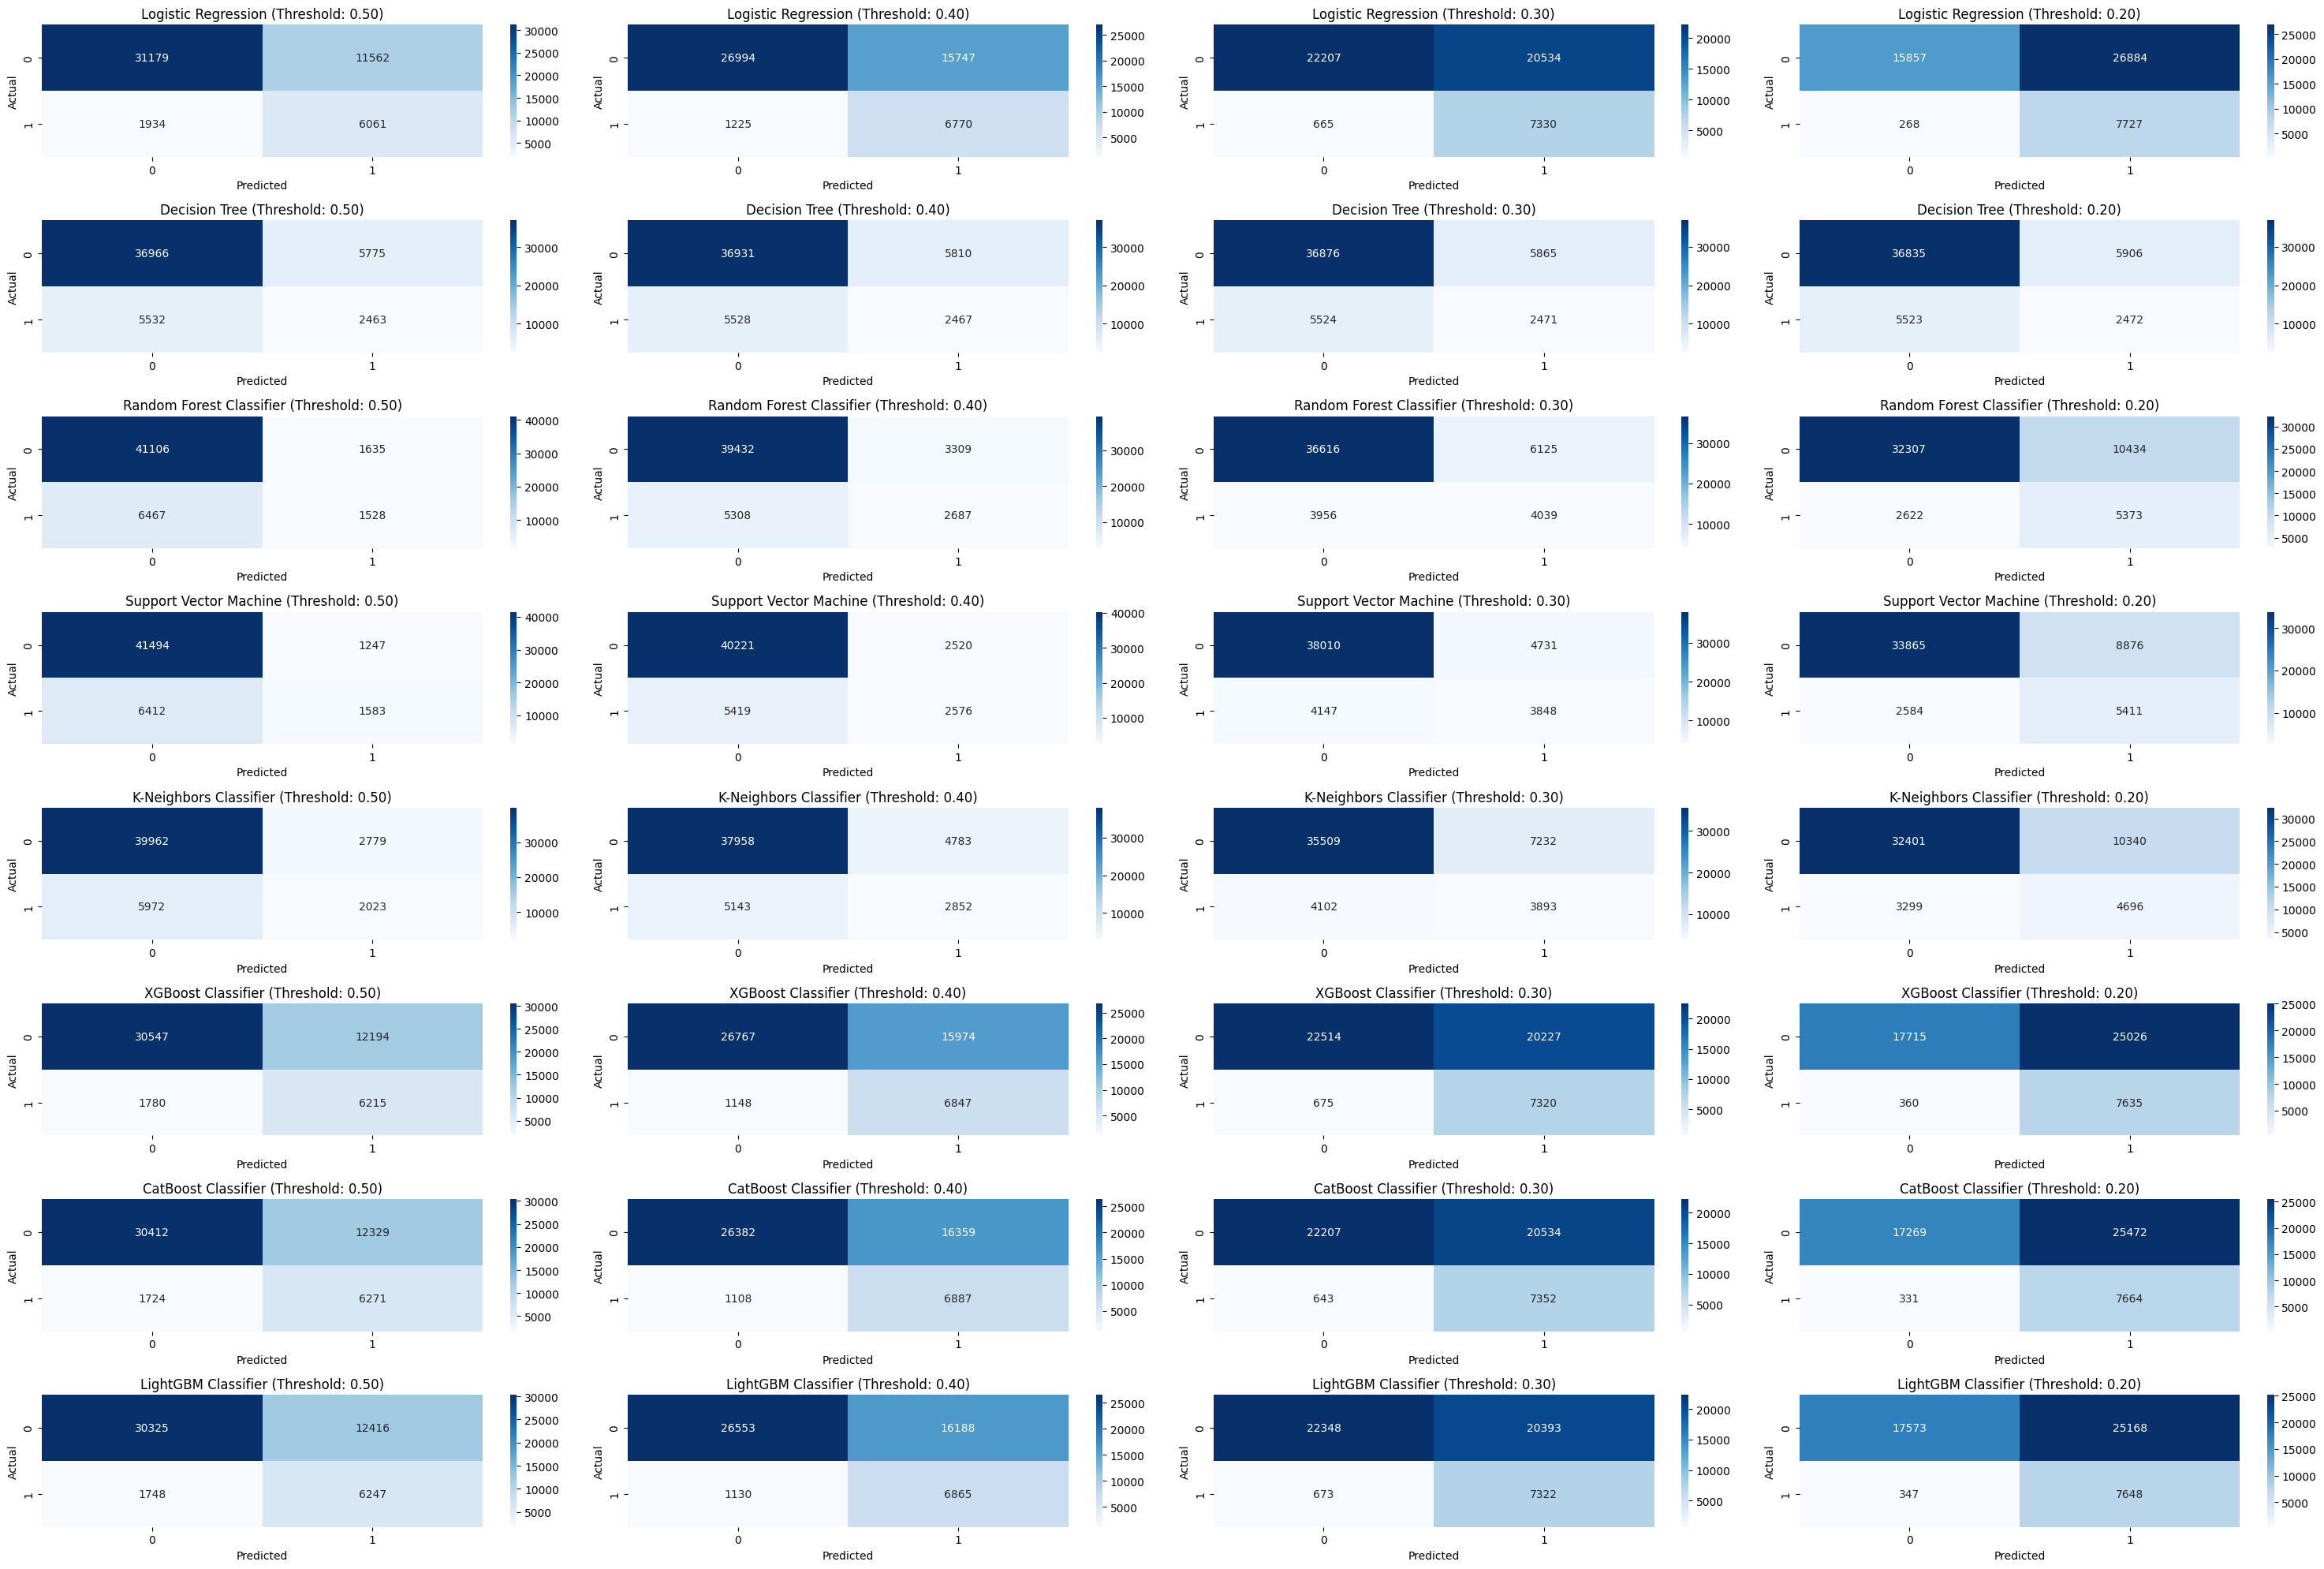

In [22]:
# Plot confusion matrices
fig, axes = plt.subplots(nrows=8, ncols=4, figsize=(30, 20))

for i, matrix in enumerate(confusion_matrix_list):
    row = i // 4
    col = i % 4
    sns.heatmap(matrix, annot=True, fmt='d', cmap="Blues", ax=axes[row, col])
    axes[row, col].set_xlabel("Predicted")
    axes[row, col].set_ylabel("Actual")
    axes[row, col].set_title(model_list[i] + " (Threshold: {:.2f})".format(threshold_list[i]))

plt.tight_layout()
plt.show()

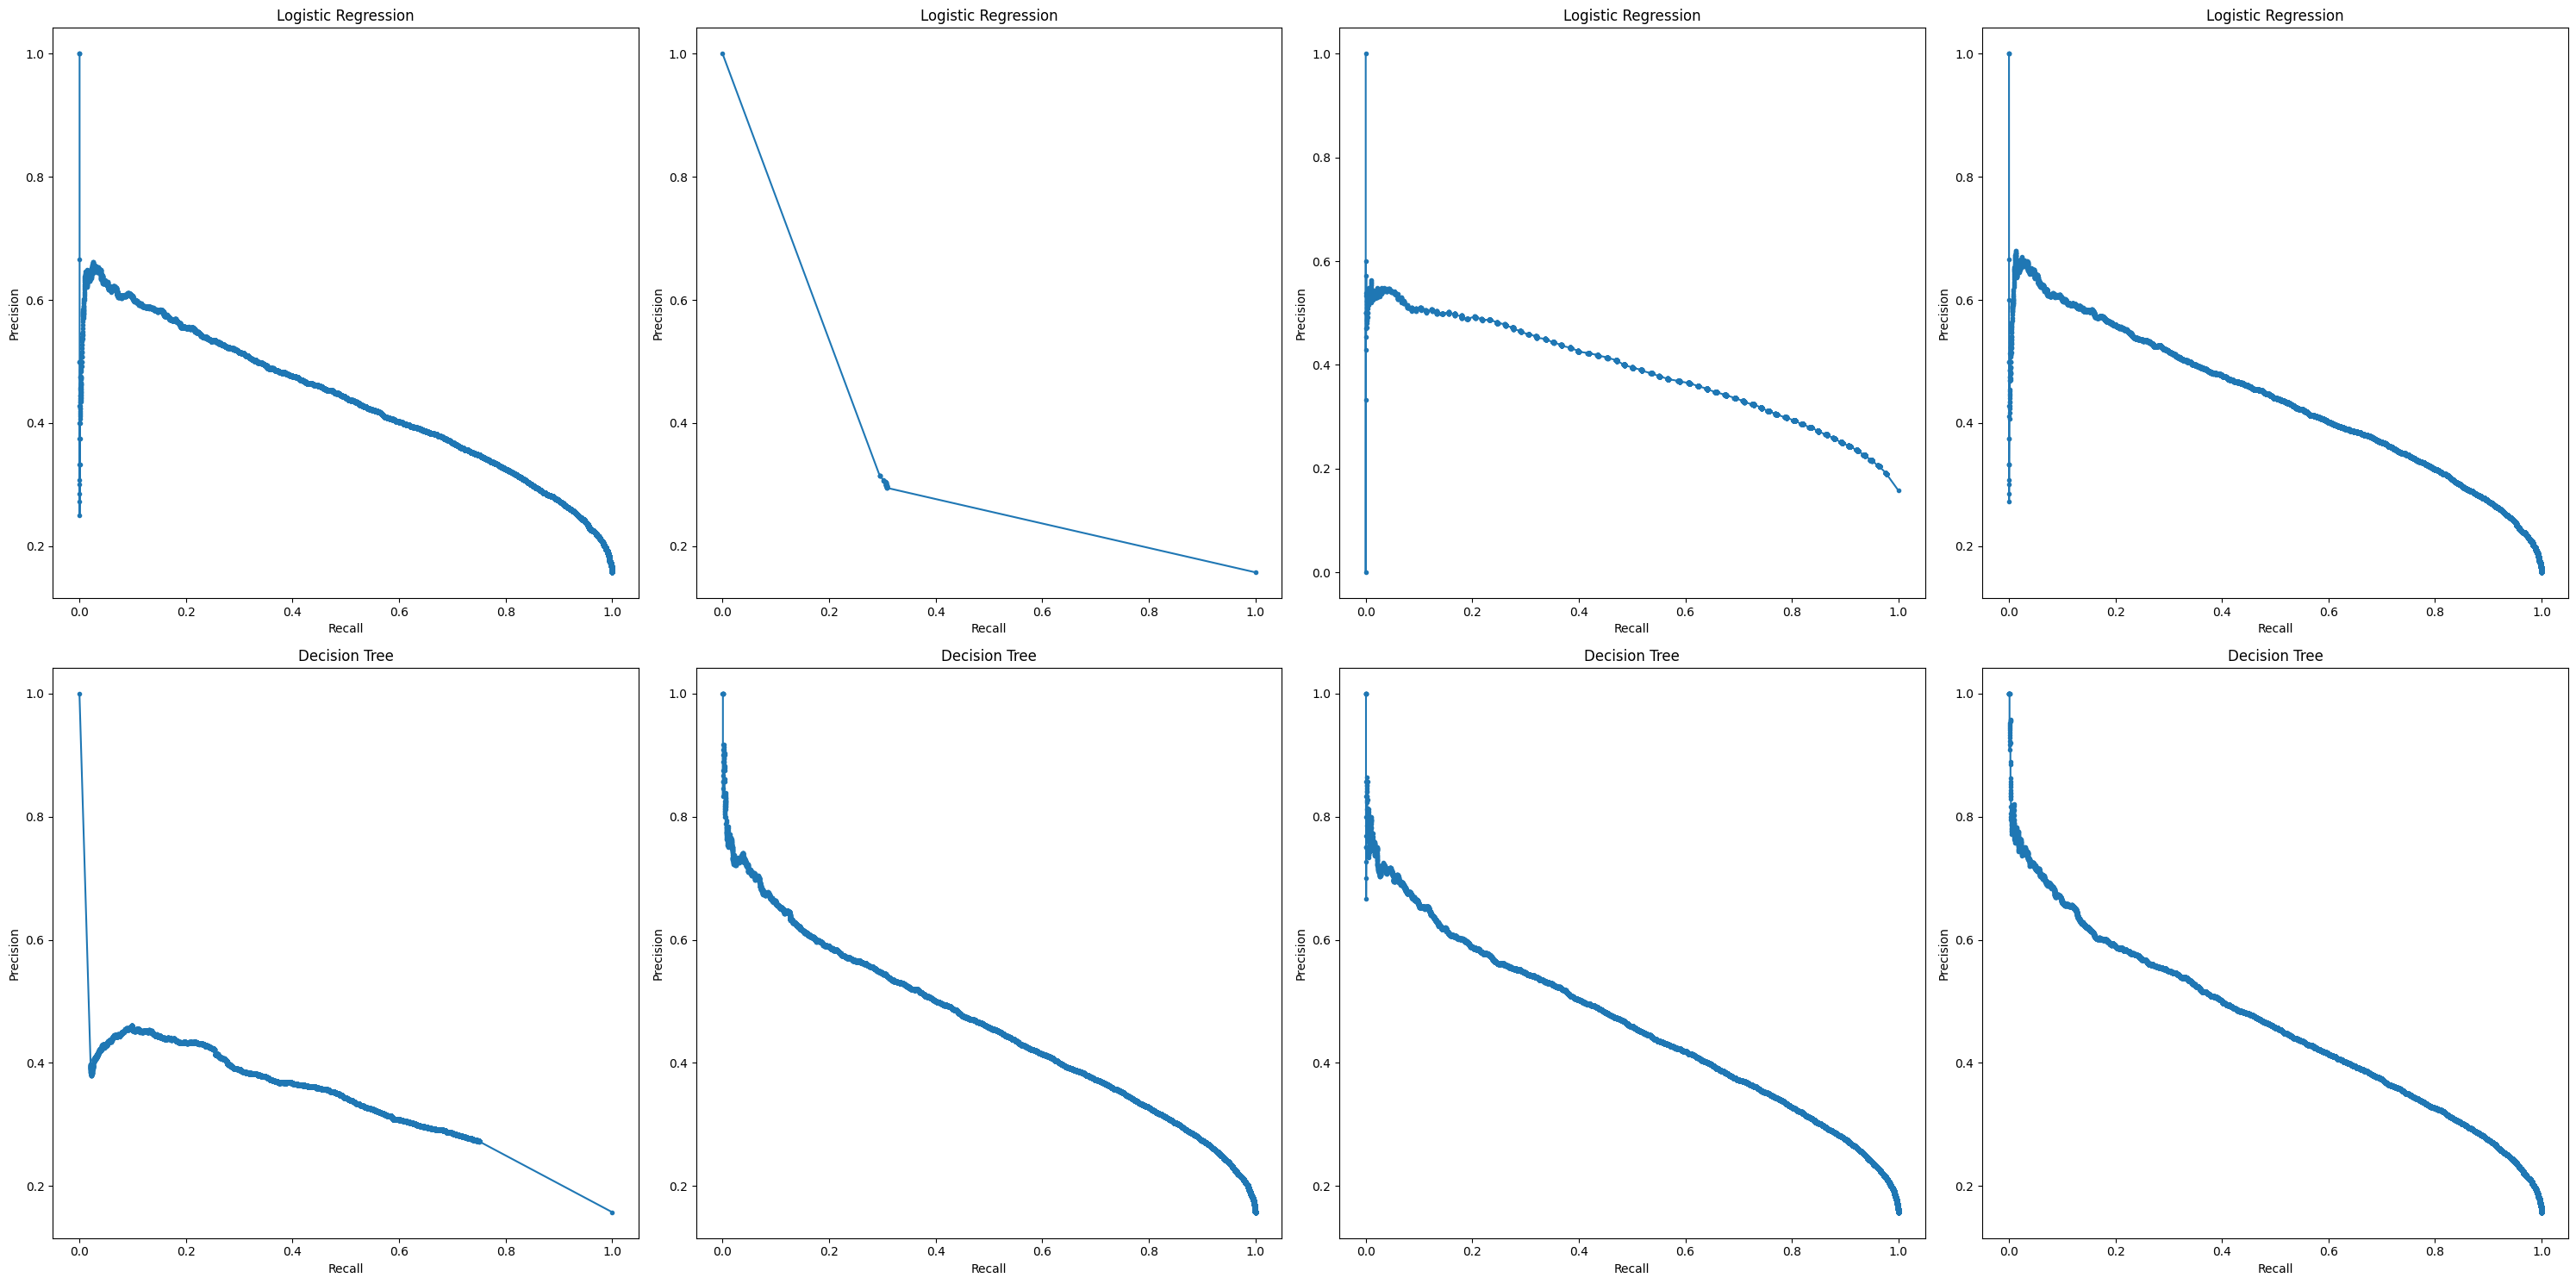

In [39]:
# Plot Precision-Recall curves
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))

for i, curve in enumerate(pr_curve_list):
    row = i // 4
    col = i % 4
    precision, recall, thresholds = curve
    axes[row, col].plot(recall, precision, marker='.')
    axes[row, col].set_xlabel("Recall")
    axes[row, col].set_ylabel("Precision")
    axes[row, col].set_title(model_list[i])

plt.tight_layout()
plt.show()


In [50]:
# Find best threshold for each model to maximize precision while maintaining recall above 0.8
target_recall = 0.75

for model in range(0, len(model_list), 4):
    best_threshold = 0
    best_precision = 0

    precision, recall, thresholds = pr_curve_list[model // 4]

    for t in range(len(thresholds)):
        if recall[t] >= target_recall:
            if precision[t] > best_precision:
                best_precision = precision[t]
                best_threshold = thresholds[t]
        
    print("Best threshold for {}: {:.2f} with precision {:.4f} and recall {:.4f}".format(model_list[model], best_threshold, best_precision, target_recall))

Best threshold for Logistic Regression: 0.51 with precision 0.3480 and recall 0.7500
Best threshold for Decision Tree: 0.00 with precision 0.1576 and recall 0.7500
Best threshold for Random Forest Classifier: 0.16 with precision 0.3116 and recall 0.7500
Best threshold for Support Vector Machine: 0.16 with precision 0.3478 and recall 0.7500
Best threshold for K-Neighbors Classifier: 0.00 with precision 0.1576 and recall 0.7500
Best threshold for XGBoost Classifier: 0.53 with precision 0.3526 and recall 0.7500
Best threshold for CatBoost Classifier: 0.53 with precision 0.3523 and recall 0.7500
Best threshold for LightGBM Classifier: 0.53 with precision 0.3496 and recall 0.7500


After class balancing and threshold testing, XGBoost, CatBoost, and LightGBM all had the best metrics. These models had a recall of 0.8 and a precision of 0.327 at threshold 0.48. I am going to focus on these three models and try to slightly reduce the class weighting and potentially try probability calibration.